Accuracy: 0.7877094972067039
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



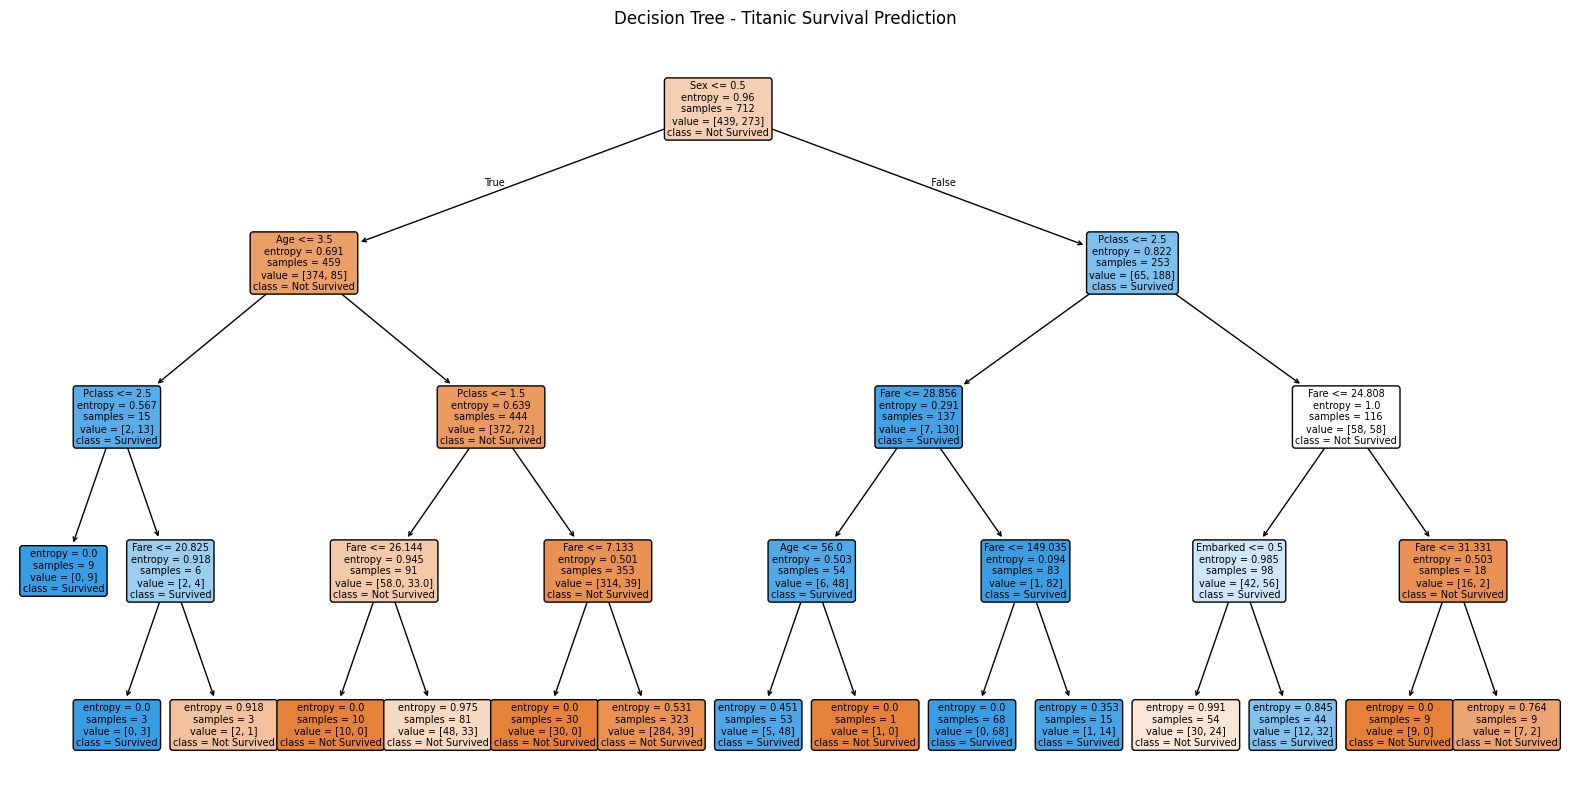

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("train.csv")
df.head()
df = df[["Survived", "Pclass", "Sex", "Age", "Fare", "Embarked"]]


# Handle missing values:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])



# Convert text → numbers:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})


# Split Features & Target
X = df.drop("Survived", axis=1)
y = df["Survived"]


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Train Decision Tree Model
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)


# Predictions
y_pred = model.predict(X_test)


# Accuracy Check
print("Accuracy:", accuracy_score(y_test, y_pred))


# Classification Report
print(classification_report(y_test, y_pred))


# Decision Tree Visualization
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Titanic Survival Prediction")
plt.show()



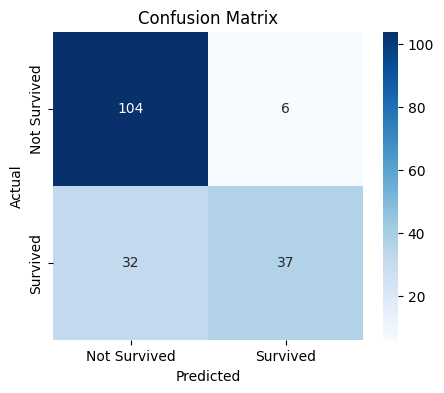

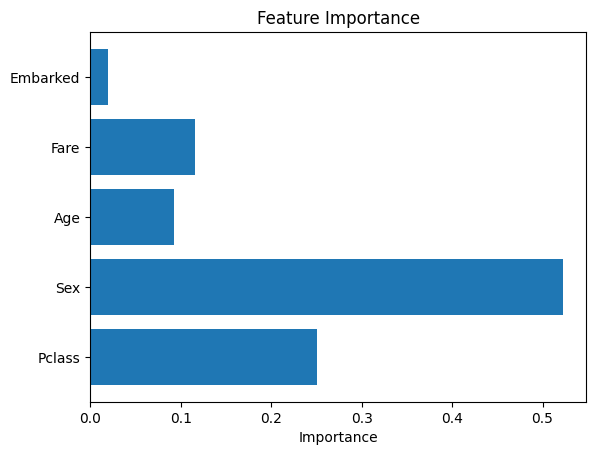

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Feature Importance
importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [7]:
# ## Analysis

# - The dataset used is Titanic survival dataset.
# - Decision Tree model was trained to predict passenger survival.
# - Features like Sex and Pclass were highly important.
# - Female passengers had higher survival probability.
# - Model performance was evaluated using accuracy and confusion matrix.
# - The tree visualization helps understand decision rules clearly.

# ## Conclusion

# A Decision Tree classifier was successfully built to predict Titanic survival.
# The model was trained, evaluated, and visualized.
# Feature importance showed key factors affecting survival.